In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from numpy.random import seed
from numpy.random import normal
import pandas as pd
import pickle
import time
import warnings
import itertools
from typing import Dict
import math
import datetime
import statistics
from scipy.linalg import eig

# Turn off FutureWarning
warnings.filterwarnings("ignore")


##Interaction matrix of residents and mutants species with x trait values 
def A_res_mut(x_trait,sigma):
    diff = np.subtract.outer(x_trait, x_trait)
    #diff2 =np.subtract.outer(y_trait, y_trait)
    result = np.exp(-np.power(diff,2 )/(2*sigma**2))
    return result

#Resource competition
def r_kennel(x_trait,sigmar):
    growth = []
    for x in x_trait[0::]:
        growth.append(np.maximum(np.exp(-np.power((x),2)/(2*sigmar**2))-0.0002, 0))
    return np.array(growth)

#Variance and Expectation

def off_diag_expect_var(matrix):
    # Extract the off-diagonal entries of the matrix
    n = matrix.shape[0]
    off_diag_entries = []
    
    for i in range(n):
        for j in range(i+1, n):
            off_diag_entries.append(matrix[i][j])
    
    var_x = np.var(off_diag_entries)
    mean = np.mean(off_diag_entries)
    
    return mean, var_x,off_diag_entries


def jaccard_similarity(d: Dict[int, list], step_size: int = 5, num_keys: int = 10) -> Dict:
    result = {}
    keys = list(d.keys())[-num_keys:]
    for i in keys:
        for j in keys:
            if abs(i - j) == step_size:
                set_i = set(d[i])
                set_j = set(d[j])
                intersection = len(set_i.intersection(set_j))
                union = len(set_i.union(set_j))
                if union != 0:
                    result[(i, j)] = intersection / union
                else:
                    result[(i, j)]=0
    return result

def hill_number(abundances, q):
    p = abundances / abundances.sum()
    if q == 0:
        return len(p)
    else:
        return np.power(np.sum(np.power(p, q)), -1 / (q - 1))
    
    
def Combinations(number):
    
    # Define the possible values for each parameter
     # Generate n random floats between 0 and 1 without repeats
    param1= random.sample([random.uniform(0.5, 1) for i in range(1000)],number)#[round(random.random(),4) for _ in range(10)]
    param2= random.sample([random.uniform(0, 0.5) for i in range(1000)], number)

    # Generate n random integers without repeats
    param3=[random.uniform(0, 5) for _ in range(number)]
    ##print(len(Combinations))

    # Generate all possible combinations of values for the three parameters
    Combinations = list(itertools.product(param1, param2, param3))
    #print(combinations)
    # Print each combination
    #for combination in Combinations:
        #param1, param2, param3 = combination
        #print(f"param1: {param1}, param2: {param2}, param3: {param3}")
        #print(combination)
    return Combinations


def introduction_rate_mean(Dict,n_iterations):
    #print(len(Intro))    
    #print(cp1)
    last_ = list(Dict.values())[-n_iterations:]
    #Intro_mean = sum(last_)/ len(last_)
    Intro_mean = statistics.mean(last_)
    Intro_variance = statistics.variance(last_)
    return Intro_mean, Intro_variance
    

def RAO_(list_1, list_2):
    #RAO
    differences = []
    proportions = []

    sum_list_1 = sum(list_1)
    sum_list_2 = sum(list_2)

    for i in range(len(list_1) - 1):
        for j in range(i+1, len(list_1)):
            diff = list_1[j] - list_1[i]
            differences.append(diff**2)
            proportion_i = list_2[i] / sum_list_2
            proportion_j = list_2[j] / sum_list_2
            proportions.append(proportion_i * proportion_j)

    result = sum([diff * prop for diff, prop in zip(differences, proportions)])
    #RAO[i] = result
    return result

def RAO_mean_(Dict, n_iterations):
    #RAO_mean
    m = list(Dict.values())[-n_iterations:]
    m_mean = statistics.mean(m)
    m_variance = statistics.variance(m)
    return m_mean,m_variance

def functional_turnover(Dict, lag,n_iterations):
    my_dict=Dict
    #Function turnover
    differences = []

    for i, key1 in enumerate(my_dict):
        for j in range(i + lag, len(my_dict)):
            key2 = list(my_dict.keys())[j]
            diff = my_dict[key2] - my_dict[key1]
            differences.append(diff) #removed abs
    if len(differences[-n_iterations:])!= 0:
        mean= sum(differences[-n_iterations:])/ len(differences[-n_iterations:])
    else:
        mean=0
    #DeltaRAO1[params] = mean
    return mean

def trait_var(Dict,n_iterations):
    t_variances = {}
    for inner_key, inner_value in Dict.items():
        if inner_value:
            mean = sum(inner_value[-n_iterations:]) / len(inner_value[-n_iterations:])
            variance = sum((x - mean) ** 2 for x in inner_value[-n_iterations:]) / len(inner_value[-n_iterations:])
            t_variances[inner_key] = variance
        else:
            t_variances[inner_key] = 0

    if len(list(t_variances.values())) != 0:
        t_variance = np.var(list(t_variances.values()), ddof=1)
    else:
        t_variance = 0
    #Trait_var[params] = t_variance
    return t_variance

def trait_mean_(Dict,n_iterations):
    t_means = {}
    for inner_key, inner_value in Dict.items():
        if inner_value:
            t_means[inner_key] = sum(inner_value[-n_iterations:]) / len(inner_value[-n_iterations:])
        else:
            t_means[inner_key] = 0

    t_mean = sum(list(t_means.values()))/len(list(t_means.values()))
    #trait_mean[params] = t_mean
    return t_mean

def mean_abundances(Dict,n_iterations):
    ssp=[]
    for k,var in Dict.items():
        ssp.append(var)
    #ssp
    # creating dataframe
    row_sum = []
    df = pd.DataFrame(ssp[-n_iterations:])
    df.fillna(0)
    ro_sum = df.sum(axis=1)
    if len(ro_sum) != 0:
        ab_mean= sum(ro_sum)/len(ro_sum)
    else:
        ab_mean = 0
    return ab_mean
def mean_inter_strength(Dict,n_iterations):
    aij_means = {}
    #print(len(aij))
    for inner_key, inner_value in Dict.items():
        #print(inner_key)
        aij_means[inner_key] = off_diag_expect_var(inner_value)[0] 
    #print('ll=',aij_means)
    if len(list(aij_means.values())[-n_iterations:])!=0:
           aij_mean = sum(list(aij_means.values())[-n_iterations:])/len(list(aij_means.values())[-n_iterations:])
    else:
           aij_mean =0
    return aij_mean
def var_inter_str(Dict,n_iterations):
    aij_variances = {}
    for inner_key, inner_value in Dict.items():
        if inner_value.any():
            mean =off_diag_expect_var(inner_value)[0]
            variance = off_diag_expect_var(inner_value)[1]
            aij_variances[inner_key] = variance
        else:
            aij_variances[inner_key] = 0
    #print('varai', aij_variances)
    if len(list(aij_variances.values())[-n_iterations:]) != 0:
        aij_variance = np.mean(list(aij_variances.values())[-n_iterations:])
    else:
        aij_variance = 0
    return aij_variance

def growth_rate_mean(Dict,n_iterations):
    ri_means = {}
    for inner_key, inner_value in Dict.items():
        if inner_value.any():
            ri_means[inner_key] = sum(inner_value[-n_iterations:]) / len(inner_value[-n_iterations:])
        else:
            ri_means[inner_key] = 0

    ri_mean = sum(list(ri_means.values()))/len(list(ri_means.values()))
    return ri_mean

def growth_rate_var(Dict,n_iterations):
    ri_variances = {}
    for inner_key, inner_value in Dict.items():
        if inner_value.any():
            mean = sum(inner_value[-n_iterations:]) / len(inner_value[-n_iterations:])
            variance = sum((x - mean) ** 2 for x in inner_value[-n_iterations:]) / len(inner_value[-n_iterations:])
            ri_variances[inner_key] = variance
        else:
            ri_variances[inner_key] = 0

    if len(list(ri_variances.values())) != 0:
        ri_variance = np.var(list(ri_variances.values()), ddof=1)
    else:
        ri_variance = 0
    return ri_variance

def Jaccard_mean(Dict, num, last_iterations):
    result = jaccard_similarity(Dict,num,last_iterations)
    merged_dict = {}
    for key, value in result.items():
        if key[::-1] in merged_dict:
            merged_dict[key[::-1]] = (merged_dict[key[::-1]] + value) / 2
        else:
            merged_dict[key] = value

    a = list(merged_dict.values())
    if len(a) != 0:
        j_mean=sum(a)/len(a)
    else:
        j_mean = 0
    return j_mean

import numpy as np


from scipy.linalg import eig

def power_iteration_all_eigenvalues(A):
    try:
        A = np.asarray(A)
        n = A.shape[0]
        
        if n == 0:
            # Empty matrix - return zero
            return 0.0
        
        # Compute eigenvalues and eigenvectors using eigh
        eigenvalues, _ = eig(A)
        
        # Check if eigenvalues array is empty
        if len(eigenvalues) == 0:
            return 0.0

        # Find the index of the maximum real part of the eigenvalues
        ind = np.argmax(np.real(eigenvalues))
        
        # Get the leading eigenvalue
        lead_eig = np.real(eigenvalues[ind])
        print(lead_eig)
        print(eigenvalues)
        
        return lead_eig
    except (ValueError, TypeError):
        # A is not a valid matrix - return zero maximum eigenvalue
        return 0.0

2024-01-03 11:17:03,084 [13444] WARNING  py.warnings:109: [JupyterRequire] C:\Users\25684752\Anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"



In [15]:

def process_combination(combination):
    # start the timer
    start_time = time.time()
    param1, param2, param3 = combination


    n,start,N_iter,n_iterations =30, 200, 1800, 1000

   
    
    #species abundances
    sp_dict={}
   
    #species richness
    cp1={}
    #species traits
    trait={}
    # list of species abundaces
    sp1=[]
    # sigmar 
    aij = {}
    #sigmar.append()
    ri = {}
    Intro = {}
    RAO = {}
    #initial number of species  
    Eig =[]
    
    #nj = list(np.random.randint(5,20,200))
    current_species=list(np.arange(0,n,1))
    #print('current_species',len(current_species))
    old_n = list(np.random.randint(0.1,3,n))
    #print('old_n',len(old_n))
    xi=np.random.uniform(-1,1,n) # x trait value
    current_xi =[var for j,var in enumerate(xi) if j in current_species]
    #print('current_s',len(nJ))
    sigmar=param1
    sigma = param2
    lam = param3

    for i in range(0,start):
        if i==0:
            im=np.full((len(current_species),),0.00)
            cp1[i]=current_species
            trait[i]=current_xi
            aij[i]= A_res_mut(current_xi,sigma)
            ri[i]= r_kennel(current_xi,sigmar)
            Intro[i] = 0
            sp1.append(list(old_n))
            d = dict(zip(current_species,old_n))
            sp_dict[i] = d
            # Function for calculating expectation
            expect = off_diag_expect_var(A_res_mut(current_xi,sigma))[0]
            var = off_diag_expect_var(A_res_mut(current_xi,sigma))[1]
            #s_starv1 = np.exp(num)*(1-expect)**2/(2*var)
            #RAO
            RAO[i] = RAO_(current_xi, old_n)

            
            
            if len(list(A_res_mut(current_xi, sigma))) != 0:
                # Calculate the eigenvalue using power iteration method
                max_eigenvalue_iteration = power_iteration_all_eigenvalues(-1*A_res_mut(current_xi, sigma))

                Eig.append(max_eigenvalue_iteration)

            else:
                Eig.append(0)
                    
        else:
            
            lambdas= 10000*(old_n*np.exp((r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n)))
            #print('lam',lambdas)
            new_n= np.random.poisson(lambdas, len(current_species))/10000
            #old_n = list(new_n)
            #print('d',d)
            cp1[i]=current_species
            trait[i]=current_xi
            aij[i]= A_res_mut(current_xi,sigma)
            ri[i]= r_kennel(current_xi,sigmar)
            Intro[i] = 0
            sp1.append(list(new_n))
            d = dict(zip(current_species,new_n))
            sp_dict[i] = d
            remove=np.array(np.where(new_n==0))
            #print(type(remove))
            keep=np.where(new_n>0)
            current_spec=[int(e) for i,e in enumerate(current_species) if i not in remove]
            #print(current_spec)
            current_species= list(np.array(current_species)[keep])
            #print('current_species',current_species)
            new_n = list(np.array(new_n)[keep])
            #print('new_n',len(new_n))
            current_xi=[var for j,var in enumerate(current_xi) if j not in remove]
            #nJ=[var for j,var in enumerate(nJ) if j not in remove]
            #print('current_xtrait',len(current_xtrait))
            old_n = list(new_n) 

            # Function for calculating expectation
            mean = off_diag_expect_var(A_res_mut(current_xi,sigma))[0]
            var = off_diag_expect_var(A_res_mut(current_xi,sigma))[1]
        
            #RAO
            RAO[i] = RAO_(current_xi, new_n)

            if len(list(A_res_mut(current_xi, sigma))) != 0:
                # Calculate the eigenvalue using power iteration method
                max_eigenvalue_iteration = power_iteration_all_eigenvalues(-1*A_res_mut(current_xi, sigma))

                Eig.append(max_eigenvalue_iteration)

            else:
                Eig.append(0)



    for i in range(start,N_iter):
        lambdas= 10000*(old_n*np.exp((r_kennel(current_xi,sigmar)-A_res_mut(current_xi,sigma)@old_n)))
        ##new_n =  poisson_pmf(len(current_species),lambdas,len(idnx))
        new_n=  np.random.poisson(lambdas, len(current_species))/10000
        #adding new species
        num=np.random.poisson(lam, size=None)
        #print(num)
        new_n= list(new_n) + list(np.full((num,),1))
        current_species= current_species + random.sample(range(10000,40000),num)
        #print('current_species',len(current_species))
        current_xi=current_xi+list(np.random.uniform(-10,10,num))
        #print('current_xi',len(current_xi))
        d = dict(zip(current_species,new_n))
        sp_dict[i] = d
        cp1[i]=current_species
        trait[i]=current_xi
        aij[i]= -1*A_res_mut(current_xi,sigma)
        ri[i]= r_kennel(current_xi,sigmar)
        Intro[i] = num
        sp1.append(list(new_n))
        remove=np.array(np.where(np.array(new_n)==0))
        #print(remove)
        keep=np.where(np.array(new_n)>0)
        #print(keep)
        current_species=[int(e) for i,e in enumerate(current_species) if i not in remove]
        #print(current_spec)
        #current_spec= list(np.array(current_spec)[keep])

        new_n = list(np.array(new_n)[keep])
        #print('new_n',len(new_n))
        current_xi=[var for j,var in enumerate(current_xi) if j not in remove]
        #print('current_xtrait',(len(current_xi)))
        #nJ =[var for j,var in enumerate(nJ) if j not in remove]

        old_n =  list(new_n) #list(new_n) + list(np.full((num,),60) )#random.sample(range(0,80),num)


        # Function for calculating expectation
        mean = off_diag_expect_var(A_res_mut(current_xi,sigma))[0]
        #print('m=',mean)
        var = off_diag_expect_var(A_res_mut(current_xi,sigma))[1]
        #print('v=',var)
    
        #RAO
        RAO[i] = RAO_(current_xi, new_n)

        
        if len(list(A_res_mut(current_xi, sigma))) != 0:
            # Calculate the eigenvalue using power iteration method
            max_eigenvalue_iteration = power_iteration_all_eigenvalues(-1*A_res_mut(current_xi, sigma))

            Eig.append(max_eigenvalue_iteration)

        else:
            Eig.append(0)           

   
    Abund2 ={}
    Current_sp = {}
    Current_sp_var = {}
    Trait_var = {}
    trait_mean = {}
    Aij = {}
    Aij_var = {}
    Ri = {}
    Ri_var = {}
    Introd = {}
    Introd_var ={}
    Jaccard_lag1={}
    Jaccard_lag5={}
    Jaccard_lag10={}
    Jaccard_lag50={}
    Jaccard_lag100={}
    Jaccard_lag200={}
    DeltaRAO1={}
    DeltaRAO5={}
    DeltaRAO10={}
    DeltaRAO50={}
    DeltaRAO100={}
    DeltaRAO200={}
    RAO_mean ={}
    RAO_var ={}
    Eigen_mean={}
    Eigen_var={}
    ##_________________________________________________________________
    Introd[combination] = introduction_rate_mean(Intro,n_iterations)[0]
    Introd_var[combination] = introduction_rate_mean(Intro,n_iterations)[1]

    #RAO_mean
    RAO_mean[combination]= RAO_mean_(RAO,n_iterations)[0]
    RAO_var[combination]= RAO_mean_(RAO,n_iterations)[1]
    #Function turnover
    DeltaRAO1[combination] = functional_turnover(RAO, 1,n_iterations)
    DeltaRAO5[combination] = functional_turnover(RAO, 5,n_iterations)
    DeltaRAO10[combination] = functional_turnover(RAO, 10,n_iterations)
    DeltaRAO50[combination] = functional_turnover(RAO, 50,n_iterations)
    DeltaRAO100[combination] = functional_turnover(RAO, 100,n_iterations)
    DeltaRAO200[combination] = functional_turnover(RAO, 200,n_iterations)

    rich_var_count = {inner_key: len(inner_value) for inner_key, inner_value in cp1.items()}
    rich_var_count_values = list(rich_var_count.values())[-n_iterations:]
    rmean = sum(rich_var_count_values) / len(rich_var_count_values) if len(rich_var_count_values) != 0 else 0
    variance = sum((x - rmean) ** 2 for x in rich_var_count_values) / len(rich_var_count_values) if len(rich_var_count_values) != 0 else 0
    Current_sp_var[combination] = variance

    #Richness
    rich_count = {inner_key: len(inner_value) for inner_key, inner_value in cp1.items()}
    last_counts = list(rich_count.values())[-n_iterations:]
    rmean = sum(last_counts) / len(last_counts) if len(last_counts) != 0 else 0
    Current_sp[combination] = rmean

    
    if len(Eig[-n_iterations:]) != 0:
        eig_mean= statistics.mean(Eig[-n_iterations:])
        eig_variance = statistics.variance(Eig[-n_iterations:])
    else:
        eig_mean = 0
        eig_variance = 0

    Eigen_mean[combination] = eig_mean
    Eigen_var[combination]=eig_variance
    #____________________________________________________________________
    #Stab5_var[combination]=st1_variance

    #variance of traits
    Trait_var[combination] = trait_var(trait,n_iterations)

    # mean of traits
    trait_mean[combination] = trait_mean_(trait,n_iterations)

    #mean of abundances
    Abund2[combination] = mean_abundances(sp_dict,n_iterations)

    # Calculate the mean of the arrays in each inner dict
    Aij[combination] = mean_inter_strength(aij,n_iterations)

    #variance of interaction strength
    Aij_var[combination] = var_inter_str(aij,n_iterations)

    #Intrinsic growth rate
    Ri[combination] = growth_rate_mean(ri,n_iterations)

    Ri_var[combination] = growth_rate_var(ri,n_iterations)

    #Jaccard_mean
    Jaccard_lag1[combination] = Jaccard_mean(cp1, 1, n_iterations)
    Jaccard_lag5[combination] = Jaccard_mean(cp1, 5, n_iterations)
    Jaccard_lag10[combination] = Jaccard_mean(cp1, 10, n_iterations)
    Jaccard_lag50[combination] = Jaccard_mean(cp1, 50, n_iterations)
    Jaccard_lag100[combination] = Jaccard_mean(cp1, 100, n_iterations)
    Jaccard_lag200[combination] = Jaccard_mean(cp1, 200, n_iterations)
    
    
    return {combination:{
        'Abund2': float(Abund2.values().__iter__().__next__()),
        'Current_sp': float(Current_sp.values().__iter__().__next__()),
        'Current_sp_var': float(Current_sp_var.values().__iter__().__next__()),
        'Trait_var': float(Trait_var.values().__iter__().__next__()),
        'trait_mean': float(trait_mean.values().__iter__().__next__()),
        'Aij': float(Aij.values().__iter__().__next__()),
        'Aij_var': float(Aij_var.values().__iter__().__next__()),
        'Ri': float(Ri.values().__iter__().__next__()),
        'Ri_var': float(Ri_var.values().__iter__().__next__()),
        'Introd': float(Introd.values().__iter__().__next__()),
        'Introd_var': float(Introd.values().__iter__().__next__()),
        'Jaccard_lag1': float(Jaccard_lag1.values().__iter__().__next__()),
        'Jaccard_lag5': float(Jaccard_lag5.values().__iter__().__next__()),
        'Jaccard_lag10': float(Jaccard_lag10.values().__iter__().__next__()),
        'Jaccard_lag50': float(Jaccard_lag50.values().__iter__().__next__()),
        'Jaccard_lag100': float(Jaccard_lag100.values().__iter__().__next__()),
        'Jaccard_lag200': float(Jaccard_lag200.values().__iter__().__next__()),
        'DeltaRAO1': float(DeltaRAO1.values().__iter__().__next__()),
        'DeltaRAO5': float(DeltaRAO5.values().__iter__().__next__()),
        'DeltaRAO10': float(DeltaRAO10.values().__iter__().__next__()),
        'DeltaRAO50': float(DeltaRAO50.values().__iter__().__next__()),
        'DeltaRAO100': float(DeltaRAO100.values().__iter__().__next__()),
        'DeltaRAO200': float(DeltaRAO200.values().__iter__().__next__()),
        'RAO_mean': float(RAO_mean.values().__iter__().__next__()),
        'RAO_var': float(RAO_var.values().__iter__().__next__()),
        'Eigen_mean': float(Eigen_mean.values().__iter__().__next__()),
        'Eigen_var': float(Eigen_var.values().__iter__().__next__())}
    }
    
    
 

In [16]:
import pandas as pd
from itertools import product

df_1 = pd.read_excel('Chapter1_spreadsheet.xlsx')

import pandas as pd

# Example DataFrame
data = df_1.iloc[:, 0:3] 

# Create a list of tuples containing values for each row
Combinations_hp = [tuple(row) for index, row in data.iterrows()]

len(Combinations_hp )

1000

In [6]:
import statistics
x=[1,2,3,4]
if len(x) != 0:
    st1_mean = statistics.mean(x)
    st1_variance = statistics.variance(x)
else:
    st1_mean = 0
    st1_variance = 0

print(st1_mean, st1_variance)

2.5 1.6666666666666667


In [18]:
from joblib import Parallel, delayed
from tqdm import tqdm
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
# start the timer
start_time = time.time()
number =10
if __name__ == '__main__':
    # Generate the list of combinations
    #param1 = random.sample([random.uniform(0.5, 1) for i in range(1000)],number)
    #param2 = random.sample([random.uniform(0, 0.5) for i in range(1000)],number)
    #param3 = [random.uniform(0, 5) for _ in range(number)]
    #combinations = list(itertools.product(param1, param2, param3))
    #with open('Combinations_hpc', 'rb') as f:
       # combinations=pickle.load(f)
    combinations=Combinations_hp 
    print("Processing started...")

    results = Parallel(n_jobs=48)(delayed(process_combination)(combination) for combination in tqdm(combinations))

    print("Processing completed.")

# Combine the results into a single dictionary
results_dict = {}
for result in results:
    results_dict.update(result)
    
file_name = f'result_{current_time}'  
with open(file_name, 'wb') as f:
    pickle.dump(results_dict,f)

A = list(results_dict.keys())

# create dataframe with columns named "Column1", "Column2", "Column3"
df_ex = pd.DataFrame(A, columns=["sigmar", "sigma", "lamda"])

dfs = []
for key, value in results_dict.items():
    #print(value)
    df = pd.DataFrame([value])
    #print(df)
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=False)
# Reset the index of combined_df
combined_df.reset_index(drop=True, inplace=True)
# Concatenate the DataFrames vertically
concatenated_final = pd.concat([df_ex , combined_df ],axis =1)

concatenated_final.to_excel(f'AAAAhpc_comp{current_time}.xlsx', index=False)
# stop the timer
end_time = time.time()
# calculate the elapsed time
elapsed_time = end_time - start_time

# print the elapsed time in seconds
print("Elapsed time:", elapsed_time, "seconds")

Processing started...


100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [2:30:27<00:00,  9.03s/it]


Processing completed.
Elapsed time: 10209.49773311615 seconds


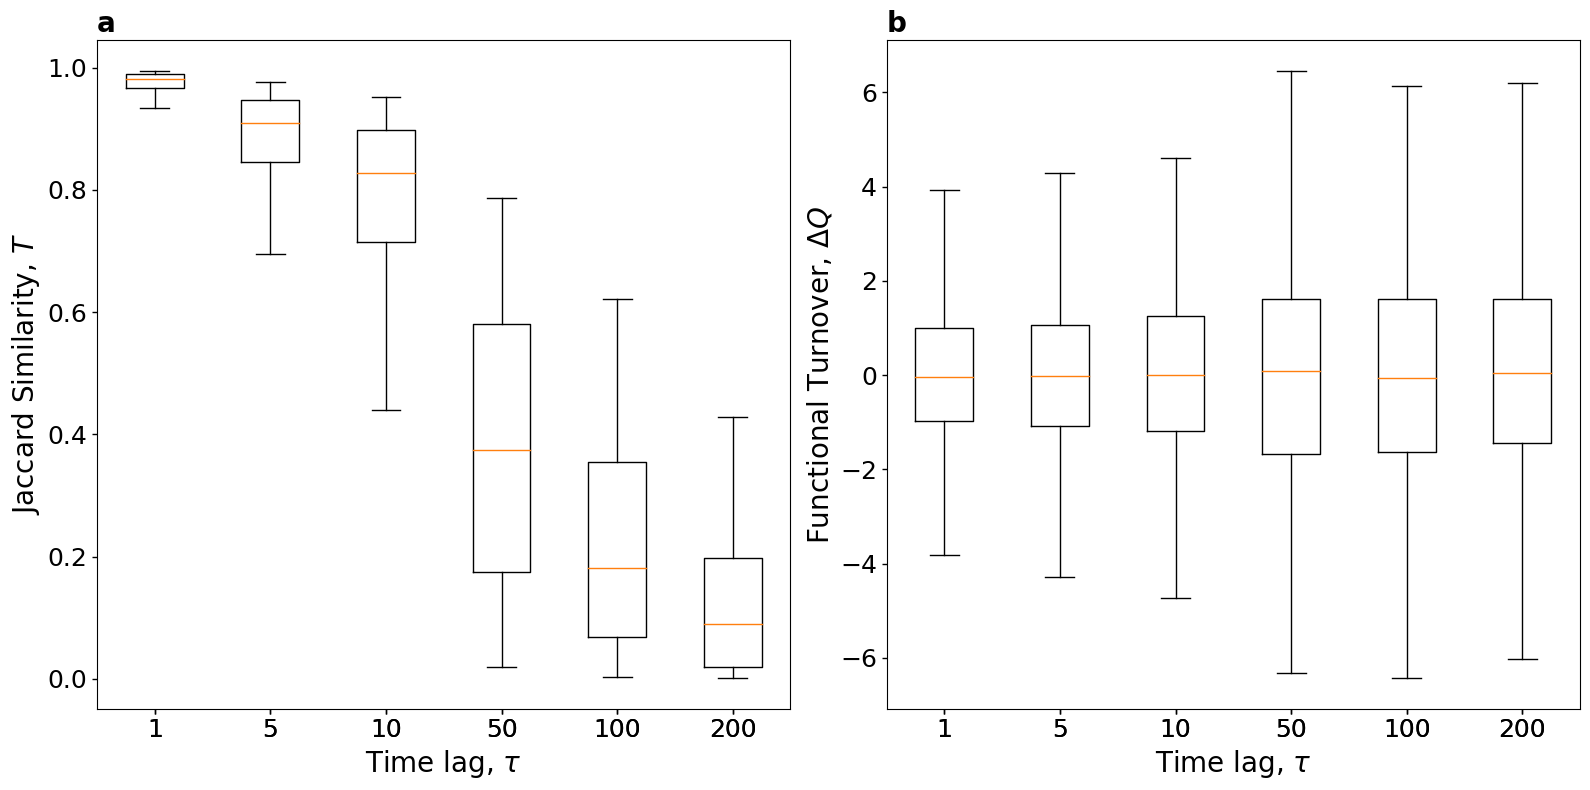

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df_1=concatenated_final
# Assuming your dataframe is named 'df' and contains the columns of interest
columns_of_interest = ['Jaccard_lag1', 'Jaccard_lag5', 'Jaccard_lag10', 'Jaccard_lag50', 'Jaccard_lag100', 'Jaccard_lag200']

# Create the figure with adjusted figsize
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharex=True, sharey='none')

# Box plots for Jaccard Similarity
axs[0].boxplot(df_1[columns_of_interest].values, labels=['1', '5', '10', '50', '100', '200'], showfliers=False)
axs[0].set_ylabel(r"Jaccard Similarity, $T$", fontsize=20)
axs[0].set_xlabel(r"Time lag, $\tau$", fontsize=20)
axs[0].tick_params(axis='both', labelsize=18)
axs[0].xaxis.set_tick_params(which='both', width=1)
axs[0].yaxis.set_tick_params(which='both', width=1)
#axs[0].text(0.5, 1.09, "a", fontsize=18, fontweight='bold', va='top', ha='left')
#axs[0].text(0, 1.1, 'a' ,rm=axs.transAxes, fontsize=18, fontweight='bold', va='top', ha='left')
# Assuming your dataframe is named 'df' and contains the columns of interest for Functional Turnover
columns_of_interest1 = ['DeltaRAO1', 'DeltaRAO5', 'DeltaRAO10', 'DeltaRAO50', 'DeltaRAO100', 'DeltaRAO200']

# Box plots for Functional Turnover
axs[1].boxplot(df_1[columns_of_interest1].values,labels=['1', '5', '10', '50', '100', '200'],showfliers=False)
axs[1].set_ylabel(r"Functional Turnover, $\Delta Q$", fontsize=20)
axs[1].set_xlabel(r"Time lag, $\tau$", fontsize=20)
axs[1].tick_params(axis='both', labelsize=18)
axs[1].xaxis.set_tick_params(which='both', width=1)
axs[1].yaxis.set_tick_params(which='both', width=1)
#axs[1].text(0.5, 10.95, "b", fontsize=18, fontweight='bold', va='top', ha='left')

axs[0].set_title("a", fontsize=20,loc="left",fontweight='bold')
axs[1].set_title("b", fontsize=20,loc="left",fontweight='bold')
# Set titles for subplots
#Set the overall title for the subplot
#plt.suptitle('Subplots of Boxplots for Two Datasets')
#axs[1].text(0, 1.1, 'b', transform=axs.transAxes, fontsize=18, fontweight='bold', va='top', ha='left')
# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

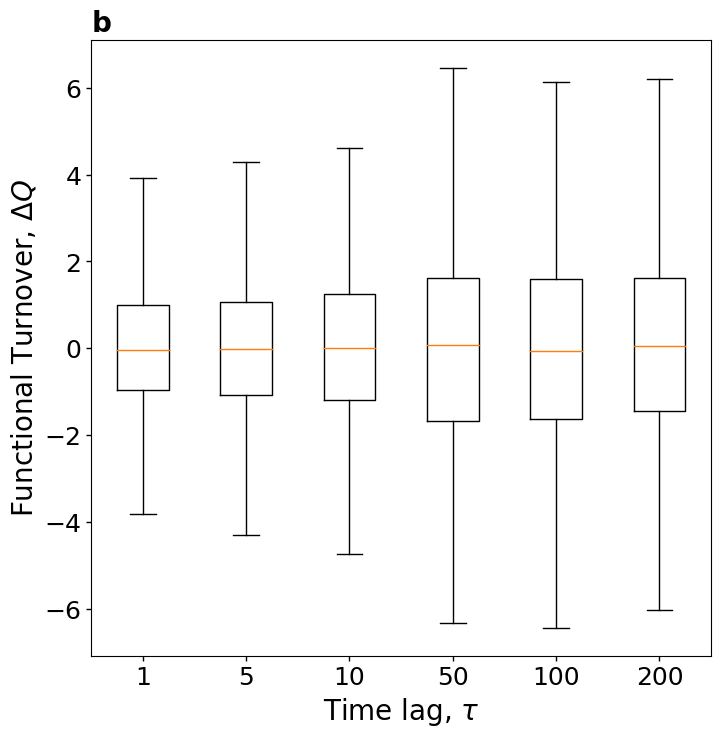

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_1 = concatenated_final

# Assuming your dataframe is named 'df' and contains the columns of interest for Functional Turnover
columns_of_interest1 = ['DeltaRAO1', 'DeltaRAO5', 'DeltaRAO10', 'DeltaRAO50', 'DeltaRAO100', 'DeltaRAO200']

# Create a figure for the second subplot only
fig, axs = plt.subplots(figsize=(8, 8))

# Box plots for Functional Turnover
axs.boxplot(df_1[columns_of_interest1].values, labels=['1', '5', '10', '50', '100', '200'], showfliers=False)

# Customize the subplot
axs.set_ylabel(r"Functional Turnover, $\Delta Q$", fontsize=20)
axs.set_xlabel(r"Time lag, $\tau$", fontsize=20)
axs.tick_params(axis='both', labelsize=18)
axs.xaxis.set_tick_params(which='both', width=1)
axs.yaxis.set_tick_params(which='both', width=1)
axs.set_title("b", fontsize=20, loc="left", fontweight='bold')

# Show the plot
plt.show()


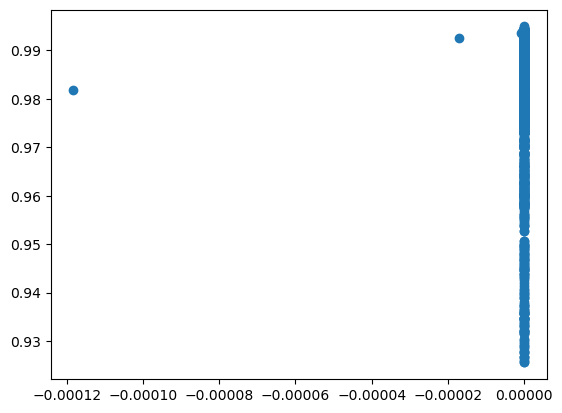

In [48]:
plt.scatter(concatenated_final["Eigen_mean"],concatenated_final["Jaccard_lag1"])

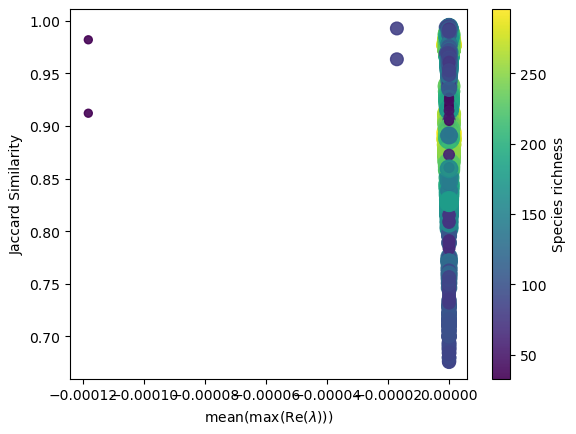

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
df_1= concatenated_final
#plt.figure(figsize=(10, 8))
# Normalize the size values to map to a colormap
norm = plt.Normalize(df_1['Current_sp'].min(), df_1['Current_sp'].max())
cmap = cm.viridis  # Choose a colormap, e.g., viridis

# Create a scatter plot
scatter = plt.scatter(df_1['Eigen_mean'], df_1['Jaccard_lag1'], s=df_1['Current_sp'], c=df_1['Current_sp'], cmap=cmap, norm=norm, alpha=0.9)
scatter = plt.scatter(df_1['Eigen_mean'], df_1['Jaccard_lag5'], s=df_1['Current_sp'], c=df_1['Current_sp'], cmap=cmap, norm=norm, alpha=0.9)
# Add labels and title
plt.xlabel(r'mean(max(Re($\lambda$)))')
plt.ylabel('Jaccard Similarity')
#plt.title('Scatter Plot with Size-Based Colors')

# Create a colorbar
cbar = plt.colorbar(scatter, label='Species richness')

# Show the plot
plt.show()


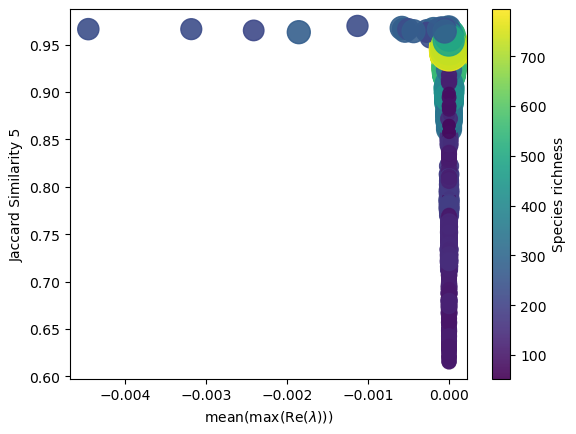

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
df_1= concatenated_final
#plt.figure(figsize=(10, 8))
# Normalize the size values to map to a colormap
norm = plt.Normalize(df_1['Current_sp'].min(), df_1['Current_sp'].max())
cmap = cm.viridis  # Choose a colormap, e.g., viridis

# Create a scatter plot
scatter = plt.scatter(df_1['Eigen_mean'], df_1['Jaccard_lag5'], s=df_1['Current_sp'], c=df_1['Current_sp'], cmap=cmap, norm=norm, alpha=0.9)

# Add labels and title
plt.xlabel(r'mean(max(Re($\lambda$)))')
plt.ylabel('Jaccard Similarity 5')
#plt.title('Scatter Plot with Size-Based Colors')

# Create a colorbar
cbar = plt.colorbar(scatter, label='Species richness')

# Show the plot
plt.show()


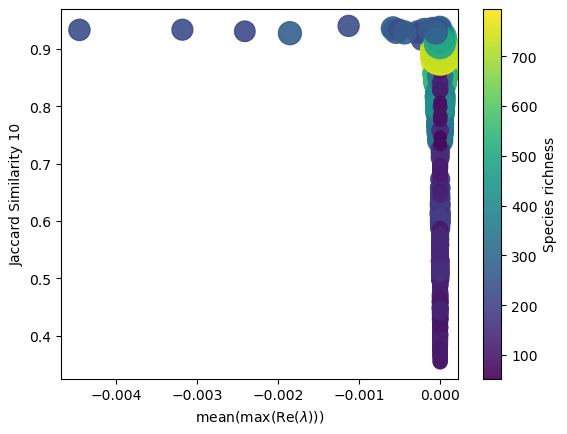

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
df_1= concatenated_final
#plt.figure(figsize=(10, 8))
# Normalize the size values to map to a colormap
norm = plt.Normalize(df_1['Current_sp'].min(), df_1['Current_sp'].max())
cmap = cm.viridis  # Choose a colormap, e.g., viridis

# Create a scatter plot
scatter = plt.scatter(df_1['Eigen_mean'], df_1['Jaccard_lag10'], s=df_1['Current_sp'], c=df_1['Current_sp'], cmap=cmap, norm=norm, alpha=0.9)

# Add labels and title
plt.xlabel(r'mean(max(Re($\lambda$)))')
plt.ylabel('Jaccard Similarity 10')
#plt.title('Scatter Plot with Size-Based Colors')

# Create a colorbar
cbar = plt.colorbar(scatter, label='Species richness')

# Show the plot
plt.show()


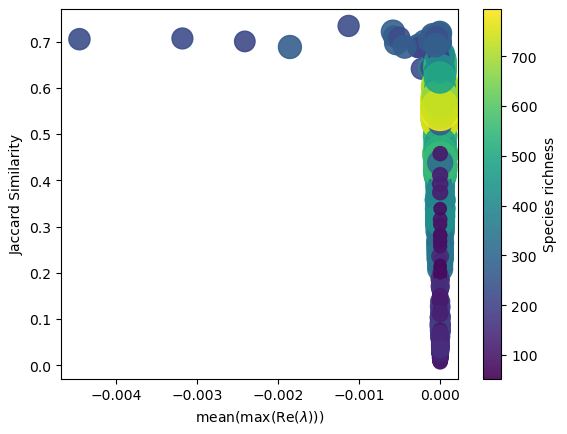

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
df_1= concatenated_final
#plt.figure(figsize=(10, 8))
# Normalize the size values to map to a colormap
norm = plt.Normalize(df_1['Current_sp'].min(), df_1['Current_sp'].max())
cmap = cm.viridis  # Choose a colormap, e.g., viridis

# Create a scatter plot
scatter = plt.scatter(df_1['Eigen_mean'], df_1['Jaccard_lag50'], s=df_1['Current_sp'], c=df_1['Current_sp'], cmap=cmap, norm=norm, alpha=0.9)

# Add labels and title
plt.xlabel(r'mean(max(Re($\lambda$)))')
plt.ylabel('Jaccard Similarity')
#plt.title('Scatter Plot with Size-Based Colors')

# Create a colorbar
cbar = plt.colorbar(scatter, label='Species richness')

# Show the plot
plt.show()


In [ ]:
plt.scatter(concatenated_final["Current_sp"],concatenated_final["Jaccard_lag1"])